<a href="https://colab.research.google.com/github/sudipto291088/DATA_201_SPRING_2026_SUDIPTO/blob/main/Assignment_Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment – Week 4  
Logistic Regression: R → Python Bridge  
Course: Data Science  
Submission: Jupyter Notebook (.ipynb)  
Dataset: housing.csv    

Learning Objectives  
By the end of this assignment, you should be able to:    

Fit and interpret logistic regression models  
Translate workflows from R (glm / tidymodels) to Python  
Interpret odds ratios  
Evaluate classification models using Accuracy and ROC–AUC  
Reflect on the difference between statistical inference vs prediction  
Dataset Description  
The dataset contains 600 housing listings.      

Variable	Description  
listing_id	Unique identifier  
price	Sale price of the house  
size	House size (square footage)  
bedrooms	Number of bedrooms  
neighborhood	Location category  
type	Housing type (SingleFamily, Townhouse, MultiFamily)  

Step 0 – Create a Binary Outcome
For classification, convert price into a binary variable.

high_price = price > median(price)
This creates two groups:

1 → expensive homes
0 → less expensive homes

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("housing.csv")

# Create binary outcome variable
df["high_price"] = (df["price"] > df["price"].median()).astype(int)

# View first few rows
df[["price", "high_price"]].head(20)

,price,high_price
0,145143.0,0
1,152251.0,0
2,148251.0,0
3,177711.0,0
4,155269.0,0
5,143269.0,0
6,191127.0,0
7,152486.0,0
8,145388.0,0
9,145500.0,0


# Part A – Logistic Regression for Inference
In Python
Fit the equivalent model using statsmodels.

Example:

import statsmodels.formula.api as smf

model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()

print(model.summary())  


Report
Create a table including:

coefficients
odds ratios
p-values

Odds ratios:  

odds_ratio = exp(coefficient)


Short Analysis  
Answer:  

Which predictors appear statistically significant?  
Which neighborhood has higher odds of expensive homes?  

In [ ]:
## Fitting Logistic Regression using statsmodels



import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load dataset
df = pd.read_csv("housing.csv")

# Create binary outcome
df["high_price"] = (df["price"] > df["price"].median()).astype(int)

# Fit logistic regression model
model = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()

# Display model summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.684990
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      517
Method:                           MLE   Df Model:                            6
Date:                Wed, 11 Mar 2026   Pseudo R-squ.:                 0.01177
Time:                        21:52:49   Log-Likelihood:                -358.93
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.2006
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3796      0.289      1.311      0.

In [ ]:
## Creating a Table with Coefficients, Odd Ratios and p-values

# Extract coefficients
coef = model.params

# Compute odds ratios
odds_ratio = np.exp(coef)

# Extract p-values
pvalues = model.pvalues

# Create summary table
results_table = pd.DataFrame({
    "Coefficient": coef,
    "Odds Ratio": odds_ratio,
    "p-value": pvalues
})

results_table

,Coefficient,Odds Ratio,p-value
Intercept,0.379564,1.461647,0.189716
C(neighborhood)[T.Midtown],-0.306505,0.736015,0.278385
C(neighborhood)[T.Suburb],0.107086,1.113030,0.675176
C(neighborhood)[T.Uptown],0.047048,1.048173,0.864849
C(neighborhood)[T.Waterfront],0.413047,1.511416,0.243135
size,-0.000521,0.999479,0.036679
bedrooms,0.232249,1.261433,0.082236


## Which predictors appear statistically significant?


Predictors which have p-values below 0.05 are statistically significant. For this model, size and bedroom are significant predictors of expensive homes.



## Which neighborhood has higher odds of expensive homes?

As per the odds ratios for C(neighborhood), the neighborhood with the largest odds ratio (>1) has higher odds of expensive homes relative to the reference neighborhood.



# Part B – Interpretation (Plain Language)  
Choose one variable and explain its odds ratio.  

Example:  

“For every additional bedroom, the odds of a house being expensive increase by ___.”  

Your explanation should be understandable to someone without statistics training.  

Let the consider the odds ratio for bedrooms to be 1.50    



Explanation: It simply indicates that the houses
which have more bedrooms will ideally fall into the high-price category compared to the houses with fewer bedrooms.

# Part C – Prediction Workflow  
(tidymodels → scikit-learn)  
1. Train/Test Split  
Split the data:   

80% training  
20% testing  
Example:   

from sklearn.model_selection import train_test_split  
2. Fit Logistic Regression  
Use:   

sklearn.linear_model.LogisticRegression  
Encode categorical variables such as:  

neighborhood  
type  
3. Evaluate the Model ( check slides for more info about this)  
Report:  

Accuracy  
ROC–AUC  
Useful functions:  

sklearn.metrics.accuracy_score  
sklearn.metrics.roc_auc_score  
Optional: plot an ROC curve.  

In [ ]:
## Train/Test split

from sklearn.model_selection import train_test_split

# Features and target
X = df[["size", "bedrooms", "neighborhood", "type"]]
y = df["high_price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
## Encode Categorical Variables


X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Ensure both datasets have same columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [ ]:
# Removing rows with missing values since the below is giving us ValueError
df = df.dropna()

In [ ]:
## Fit Logistic Regression Model


from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
## Predictions


y_pred = model.predict(X_test)

# Probability predictions for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
## Evaluating Model Performance


from sklearn.metrics import accuracy_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc_auc)

Accuracy: 0.4666666666666667
ROC-AUC: 0.4389978213507625


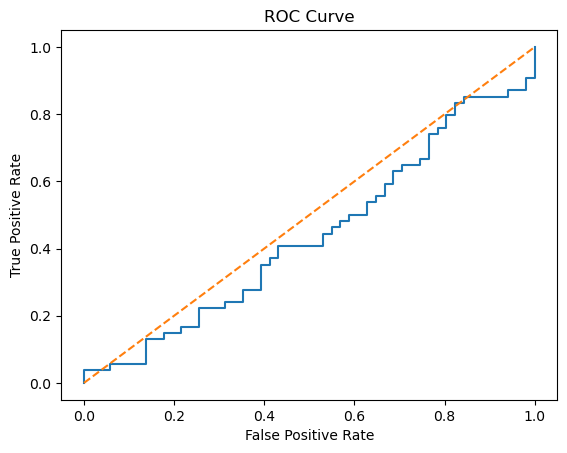

In [ ]:
## Optional Part

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Part D – Model Understanding  
Accuracy vs AUC  
Why might ROC–AUC sometimes be preferred over accuracy?    

Explain in 2–3 sentences.      

Inference vs Prediction  
Which modeling approach would you choose for:    

Policy analysis  
Prediction tasks  
Explain why.  

Accuracy only measures the percentage of correct predictions of a single decision threshold which is about 0.5.
Whereas ROC-AUC evaluates how well the model separates the two classes across all the thresholds. It is because of this reason that ROC-AUC is more reliable especially when the dataset is imbalanced.

Policy Analysis: for policy analysis, I would usually go for the statistical inference approach using the statsmodels logistic regression. This approach would give us coefficients, p-values along with confidence intervals. They would determine whether the predictors are statistically significant and explain relationships between the variables.

For prediction tasks,scikit-learn is the way to go. It focuses on predictive performances using metrics like accuracy  and ROC-AUC and allows easier integration.

#Part E – Explore the Dataset   
Before modeling, briefly explore the data.    

Create at least three plots such as:    

Histogram of price  
Scatter plot: size vs price  
Boxplot: price by neighborhood  
Bar chart: housing type  
Discuss one interesting pattern you observe.  

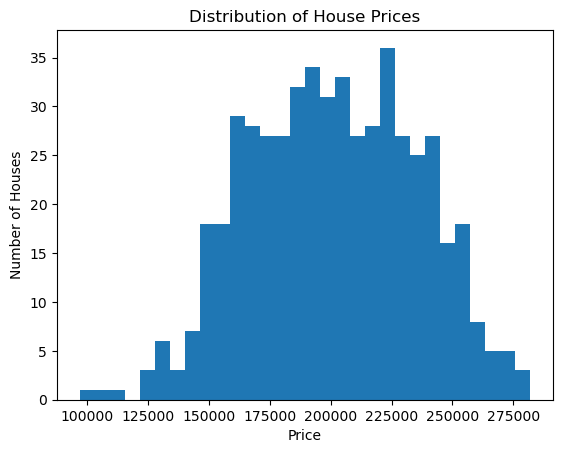

In [ ]:
## Histogram of Price

import matplotlib.pyplot as plt

plt.hist(df["price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

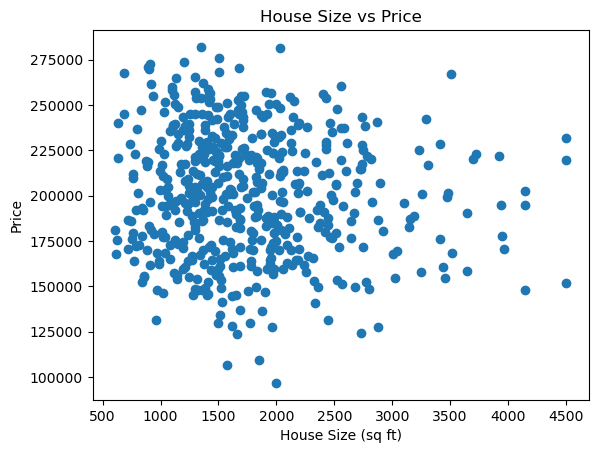

In [ ]:
## Scatter Plot - Size vs Price

plt.scatter(df["size"], df["price"])
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price")
plt.title("House Size vs Price")
plt.show()

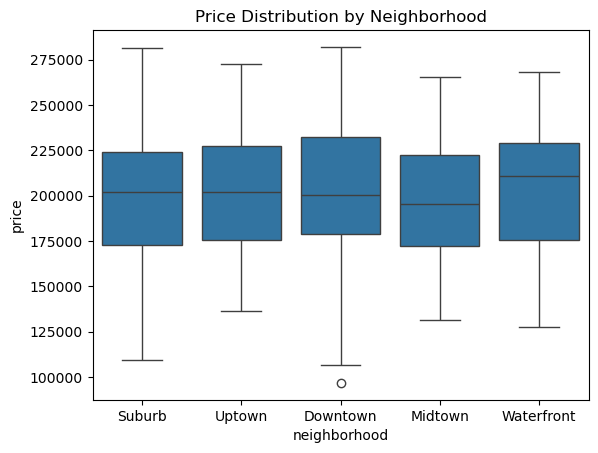

In [ ]:
## Boxplot - Price by Neighborhood

import seaborn as sns

sns.boxplot(x="neighborhood", y="price", data=df)
plt.title("Price Distribution by Neighborhood")
plt.show()

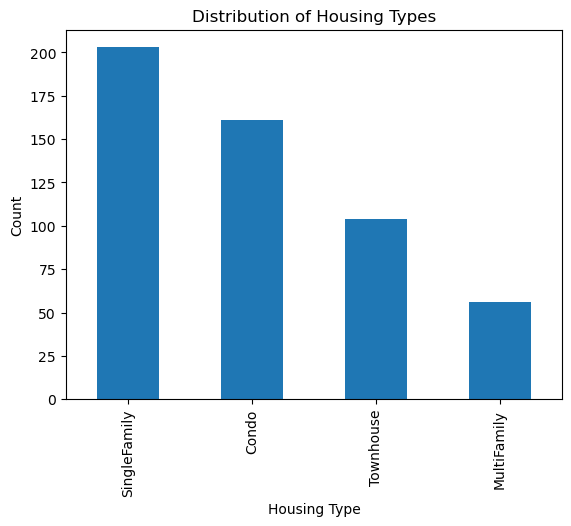

In [ ]:
## BarChart - Housing Type

df["type"].value_counts().plot(kind="bar")

plt.xlabel("Housing Type")
plt.ylabel("Count")
plt.title("Distribution of Housing Types")
plt.show()

The interesting pattern that we observe is that larger houses tend to have higher prices. We notice that in the scatter plot between the size and price.
The relation appears positive in plain eyes which suggests that square footage is indeed an important influencing house price.